# Radius and Weather Analysis for Aircraft SED

This notebook analyzes hyperparameter search results across different search radii (1-6 km) and weather conditions. It loads radius summary JSON files, aggregates performance metrics by session/weather, and generates visualizations to identify optimal radius settings.

**Key Outputs:**
- **Tidy data CSV**: All 30 fold-level results across radii with metrics
- **Aggregated summary**: Utility score by radius (accounting for skip rate)
- **Weather-radius summary**: Mean AUC and metrics by session and radius
- **7 visualization plots**: Feasibility, performance, and pattern analysis

## Section 1: Set Up the Notebook Environment

Configure matplotlib for inline display and suppress warnings.

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11
import warnings
warnings.filterwarnings('ignore')

## Section 2: Import Libraries and Configure Paths

Import required packages and define output directories.

In [21]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure output directory (where figures will be saved)
OUTPUT_DIR = Path("../outputs/radius_weather_analysis").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis


## Section 3: Load or Prepare the Data

Configure fold-to-session and session-to-weather mappings, then specify the results directory.

In [22]:
# Define mappings: fold index -> session label -> weather label
FOLD_TO_SESSION = {
    3: "Session 1",
    1: "Session 2",
    0: "Session 3",
    2: "Session 4",
    4: "Session 5",
}

SESSION_TO_WEATHER = {
    "Session 1": "Clear skies",
    "Session 2": "Snow",
    "Session 3": "Wind",
    "Session 4": "Wind and rain",
    "Session 5": "Unknown",
}

# Configure results directory (where radius_*km/radius_summary.json files are located)
RESULTS_ROOT = Path("D:/results/20260511-080325Z(experiment norwegian_only with unfrozen backbone)").resolve()
LAMBDA_SKIP_PENALTY = 0.2

print(f"Results root: {RESULTS_ROOT}")
print(f"Skip penalty (lambda): {LAMBDA_SKIP_PENALTY}")

Results root: D:\results\20260511-080325Z(experiment norwegian_only with unfrozen backbone)
Skip penalty (lambda): 0.2


In [23]:
# Utility functions for loading and parsing data
def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def extract_rows(summary_path: Path) -> list[dict[str, Any]]:
    """Extract all trained and skipped fold records from a radius_summary.json file."""
    data = load_json(summary_path)
    radius_km = float(data.get("radius_km"))

    rows: list[dict[str, Any]] = []

    # Trained folds
    for fold in data.get("fold_results", []):
        test_metrics = fold.get("test_metrics", {})
        pre = fold.get("pretrain_label_overview", {})
        test_overview = pre.get("test", {})
        val_overview = pre.get("val", {})
        train_overview = pre.get("train", {})

        rows.append({
            "radius_km": radius_km,
            "fold_id": int(fold.get("fold_id")),
            "trained": True,
            "skip_reason": "",
            "best_val_auc": fold.get("best_val_auc"),
            "best_val_loss": fold.get("best_val_loss"),
            "test_auc": test_metrics.get("auc"),
            "test_loss": test_metrics.get("loss"),
            "test_pos_rate": test_overview.get("pos_rate"),
            "val_pos_rate": val_overview.get("pos_rate"),
            "train_pos_rate": train_overview.get("pos_rate"),
            "test_total": test_overview.get("total"),
            "test_pos": test_overview.get("pos"),
            "test_neg": test_overview.get("neg"),
        })

    # Skipped folds
    for skipped in data.get("skipped_folds", []):
        pre = skipped.get("label_overview_pretrain", {})
        test_overview = pre.get("test", {})
        val_overview = pre.get("val", {})
        train_overview = pre.get("train", {})

        rows.append({
            "radius_km": radius_km,
            "fold_id": int(skipped.get("fold_id")),
            "trained": False,
            "skip_reason": skipped.get("reason", ""),
            "best_val_auc": np.nan,
            "best_val_loss": np.nan,
            "test_auc": np.nan,
            "test_loss": np.nan,
            "test_pos_rate": test_overview.get("pos_rate"),
            "val_pos_rate": val_overview.get("pos_rate"),
            "train_pos_rate": train_overview.get("pos_rate"),
            "test_total": test_overview.get("total"),
            "test_pos": test_overview.get("pos"),
            "test_neg": test_overview.get("neg"),
        })

    return rows


# Load all radius summaries
summary_paths = sorted(RESULTS_ROOT.glob("radius_*km/radius_summary.json"))
print(f"Found {len(summary_paths)} radius summary files")

rows: list[dict[str, Any]] = []
for path in summary_paths:
    rows.extend(extract_rows(path))

df = pd.DataFrame(rows)

# Add session and weather labels
df["session"] = df["fold_id"].map(FOLD_TO_SESSION).fillna(df["fold_id"].apply(lambda v: f"Fold {v}"))
df["weather"] = df["session"].map(SESSION_TO_WEATHER).fillna("Unknown")
df["session_weather"] = df["session"] + " (" + df["weather"] + ")"

print(f"Loaded {len(df)} fold records across {len(summary_paths)} radii")
print(f"\nDataFrame shape: {df.shape}")
print(f"Radii: {sorted(df['radius_km'].unique())}")
print(f"\nFirst few rows:")
df.head()

Found 6 radius summary files
Loaded 30 fold records across 6 radii

DataFrame shape: (30, 17)
Radii: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]

First few rows:


,radius_km,fold_id,trained,skip_reason,best_val_auc,best_val_loss,test_auc,test_loss,test_pos_rate,val_pos_rate,train_pos_rate,test_total,test_pos,test_neg,session,weather,session_weather
0,1.0,2,True,,0.51258,0.020116,0.354968,0.006615,0.000524,0.001274,0.013742,156582,82,156500,Session 4,Wind and rain,Session 4 (Wind and rain)
1,1.0,3,True,,0.50000,7.390380,0.114981,0.019671,0.001274,0.087926,0.000348,49446,63,49383,Session 1,Clear skies,Session 1 (Clear skies)
2,1.0,0,False,validation split has 0 positive labels; test s...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.006485,33622,0,33622,Session 3,Wind,Session 3 (Wind)
3,1.0,1,False,test split has 0 positive labels,NaN,NaN,NaN,NaN,0.000000,0.000524,0.013808,45333,0,45333,Session 2,Snow,Session 2 (Snow)
4,1.0,4,False,validation split has 0 positive labels,NaN,NaN,NaN,NaN,0.087926,0.000000,0.000577,14626,1286,13340,Session 5,Unknown,Session 5 (Unknown)


## Section 4: Define Plotting Functions

Create summary tables and plotting functions that both display inline and save to disk.

In [24]:
def summarize_by_radius(df: pd.DataFrame, skip_lambda: float) -> pd.DataFrame:
    """Aggregate metrics by radius, compute utility score."""
    grouped = df.groupby("radius_km", as_index=False).agg(
        num_folds_total=("fold_id", "count"),
        num_trained=("trained", "sum"),
        mean_best_val_auc=("best_val_auc", "mean"),
        mean_test_auc=("test_auc", "mean"),
        median_test_auc=("test_auc", "median"),
        mean_test_loss=("test_loss", "mean"),
        mean_test_pos_rate=("test_pos_rate", "mean"),
    )
    grouped["num_skipped"] = grouped["num_folds_total"] - grouped["num_trained"]
    grouped["skip_rate"] = np.where(
        grouped["num_folds_total"] > 0,
        grouped["num_skipped"] / grouped["num_folds_total"],
        np.nan,
    )
    grouped["utility"] = grouped["mean_test_auc"] - skip_lambda * grouped["skip_rate"]
    return grouped.sort_values("radius_km").reset_index(drop=True)


def summarize_by_weather_radius(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate metrics by session/weather and radius (trained folds only)."""
    weather_df = df[df["trained"]].copy()
    out = weather_df.groupby(["session", "weather", "radius_km"], as_index=False).agg(
        n=("fold_id", "count"),
        mean_test_auc=("test_auc", "mean"),
        mean_best_val_auc=("best_val_auc", "mean"),
        mean_test_loss=("test_loss", "mean"),
        mean_test_pos_rate=("test_pos_rate", "mean"),
    )
    return out.sort_values(["session", "radius_km"]).reset_index(drop=True)


# Compute summary tables
radius_summary = summarize_by_radius(df, LAMBDA_SKIP_PENALTY)
weather_radius_summary = summarize_by_weather_radius(df)

print("Radius Summary (aggregated by radius):")
print(radius_summary)
print("\n" + "="*80 + "\n")
print("Weather-Radius Summary (aggregated by session/weather and radius):")
print(weather_radius_summary.head(15))

Radius Summary (aggregated by radius):
   radius_km  num_folds_total  num_trained  mean_best_val_auc  mean_test_auc  \
0        1.0                5            2           0.506290       0.234975   
1        2.0                5            3           0.519019       0.405438   
2        3.0                5            5           0.500141       0.360636   
3        4.0                5            5           0.507559       0.516789   
4        5.0                5            5           0.510968       0.458544   
5        6.0                5            5           0.495484       0.493902   

   median_test_auc  mean_test_loss  mean_test_pos_rate  num_skipped  \
0         0.234975        0.013143            0.017945            3   
1         0.481325        0.157737            0.044285            2   
2         0.451396        1.450343            0.107589            0   
3         0.528625        1.963502            0.175623            0   
4         0.454571        3.187161           

In [25]:
def make_plots(df: pd.DataFrame, radius_summary: pd.DataFrame, out_dir: Path, show_inline: bool = True) -> None:
    """Generate all 7 analysis plots. If out_dir provided, save to disk in PDF and PNG; if show_inline=True, display in notebook."""
    sns.set_theme(style="whitegrid", context="talk")
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['font.size'] = 11

    # 1) Feasibility: trained folds by radius
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=radius_summary, x="radius_km", y="num_trained", color="#2a9d8f", ax=ax)
    ax.set_title("Trained Folds by Radius", fontfamily='Times New Roman', fontsize=13)
    ax.set_xlabel("Radius (km)", fontfamily='Times New Roman')
    ax.set_ylabel("Number of Trained Folds", fontfamily='Times New Roman')
    fig.tight_layout()
    if out_dir:
        pdf_path = out_dir / "01_trained_folds_by_radius.pdf"
        png_path = out_dir / "01_trained_folds_by_radius.png"
        fig.savefig(pdf_path, dpi=220, format='pdf')
        fig.savefig(png_path, dpi=220, format='png')
        print(f"  ✓ Saved: {pdf_path}")
        print(f"  ✓ Saved: {png_path}")
    if show_inline:
        plt.show()
    else:
        plt.close(fig)

    # 2) Feasibility: skip rate by radius
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=radius_summary, x="radius_km", y="skip_rate", color="#e76f51", ax=ax)
    ax.set_title("Skip Rate by Radius", fontfamily='Times New Roman', fontsize=13)
    ax.set_xlabel("Radius (km)", fontfamily='Times New Roman')
    ax.set_ylabel("Skip Rate", fontfamily='Times New Roman')
    fig.tight_layout()
    if out_dir:
        pdf_path = out_dir / "02_skip_rate_by_radius.pdf"
        png_path = out_dir / "02_skip_rate_by_radius.png"
        fig.savefig(pdf_path, dpi=220, format='pdf')
        fig.savefig(png_path, dpi=220, format='png')
        print(f"  ✓ Saved: {pdf_path}")
        print(f"  ✓ Saved: {png_path}")
    if show_inline:
        plt.show()
    else:
        plt.close(fig)

    # 3) Positive rate by radius
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.lineplot(data=radius_summary, x="radius_km", y="mean_test_pos_rate", marker="o", ax=ax)
    ax.set_title("Mean Test Positive Rate by Radius", fontfamily='Times New Roman', fontsize=13)
    ax.set_xlabel("Radius (km)", fontfamily='Times New Roman')
    ax.set_ylabel("Mean Test Positive Rate", fontfamily='Times New Roman')
    fig.tight_layout()
    if out_dir:
        pdf_path = out_dir / "03_test_pos_rate_by_radius.pdf"
        png_path = out_dir / "03_test_pos_rate_by_radius.png"
        fig.savefig(pdf_path, dpi=220, format='pdf')
        fig.savefig(png_path, dpi=220, format='png')
        print(f"  ✓ Saved: {pdf_path}")
        print(f"  ✓ Saved: {png_path}")
    if show_inline:
        plt.show()
    else:
        plt.close(fig)

    trained = df[df["trained"]].copy()

    # 4) Heatmap: session_weather x radius (test AUC)
    heat_df = trained.pivot_table(index="session_weather", columns="radius_km", values="test_auc", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title("Test AUC by Session and Radius", fontfamily='Times New Roman', fontsize=13)
    ax.set_xlabel("Radius (km)", fontfamily='Times New Roman')
    ax.set_ylabel("Session (Weather)", fontfamily='Times New Roman')
    fig.tight_layout()
    if out_dir:
        pdf_path = out_dir / "04_heatmap_auc_weather_radius.pdf"
        png_path = out_dir / "04_heatmap_auc_weather_radius.png"
        fig.savefig(pdf_path, dpi=220, format='pdf')
        fig.savefig(png_path, dpi=220, format='png')
        print(f"  ✓ Saved: {pdf_path}")
        print(f"  ✓ Saved: {png_path}")
    if show_inline:
        plt.show()
    else:
        plt.close(fig)

    # 5) Line plot: radius vs test AUC by weather
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=trained, x="radius_km", y="test_auc", hue="session_weather", marker="o", ax=ax)
    ax.set_title("Test AUC vs Radius by Session and Weather", fontfamily='Times New Roman', fontsize=13)
    ax.set_xlabel("Radius (km)", fontfamily='Times New Roman')
    ax.set_ylabel("Test AUC", fontfamily='Times New Roman')
    ax.legend(title="Session (Weather)", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=True)
    fig.tight_layout()
    if out_dir:
        pdf_path = out_dir / "05_lines_auc_by_weather.pdf"
        png_path = out_dir / "05_lines_auc_by_weather.png"
        fig.savefig(pdf_path, dpi=220, format='pdf', bbox_inches="tight")
        fig.savefig(png_path, dpi=220, format='png', bbox_inches="tight")
        print(f"  ✓ Saved: {pdf_path}")
        print(f"  ✓ Saved: {png_path}")
    if show_inline:
        plt.show()
    else:
        plt.close(fig)

    # 6) Distribution by radius
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=trained, x="radius_km", y="test_auc", ax=ax)
    sns.stripplot(data=trained, x="radius_km", y="test_auc", color="black", alpha=0.5, ax=ax)
    ax.set_title("Distribution of Test AUC Across Folds by Radius", fontfamily='Times New Roman', fontsize=13)
    ax.set_xlabel("Radius (km)", fontfamily='Times New Roman')
    ax.set_ylabel("Test AUC", fontfamily='Times New Roman')
    fig.tight_layout()
    if out_dir:
        pdf_path = out_dir / "06_box_auc_by_radius.pdf"
        png_path = out_dir / "06_box_auc_by_radius.png"
        fig.savefig(pdf_path, dpi=220, format='pdf')
        fig.savefig(png_path, dpi=220, format='png')
        print(f"  ✓ Saved: {pdf_path}")
        print(f"  ✓ Saved: {png_path}")
    if show_inline:
        plt.show()
    else:
        plt.close(fig)

    # 7) AUC vs prevalence
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(data=trained, x="test_pos_rate", y="test_auc", hue="radius_km", style="session_weather", s=90, ax=ax)
    ax.set_title("Test AUC vs Test Positive Rate", fontfamily='Times New Roman', fontsize=13)
    ax.set_xlabel("Test Positive Rate", fontfamily='Times New Roman')
    ax.set_ylabel("Test AUC", fontfamily='Times New Roman')
    fig.tight_layout()
    if out_dir:
        pdf_path = out_dir / "07_scatter_auc_vs_test_pos_rate.pdf"
        png_path = out_dir / "07_scatter_auc_vs_test_pos_rate.png"
        fig.savefig(pdf_path, dpi=220, format='pdf', bbox_inches="tight")
        fig.savefig(png_path, dpi=220, format='png', bbox_inches="tight")
        print(f"  ✓ Saved: {pdf_path}")
        print(f"  ✓ Saved: {png_path}")
    if show_inline:
        plt.show()
    else:
        plt.close(fig)
    
    if out_dir:
        print(f"\n✅ All figures saved to: {out_dir}")

## Section 5: Display Figures Inline in the Notebook

Generate and display all 7 visualization plots within the notebook.

Generating figures for display...



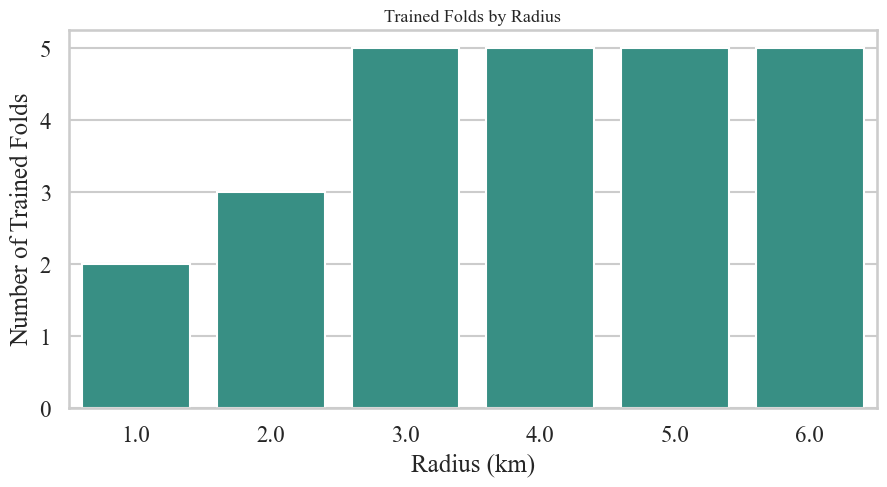

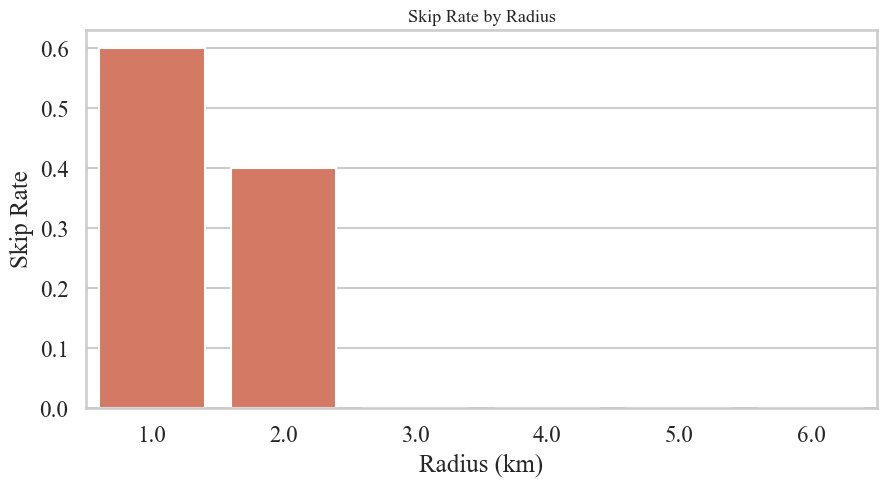

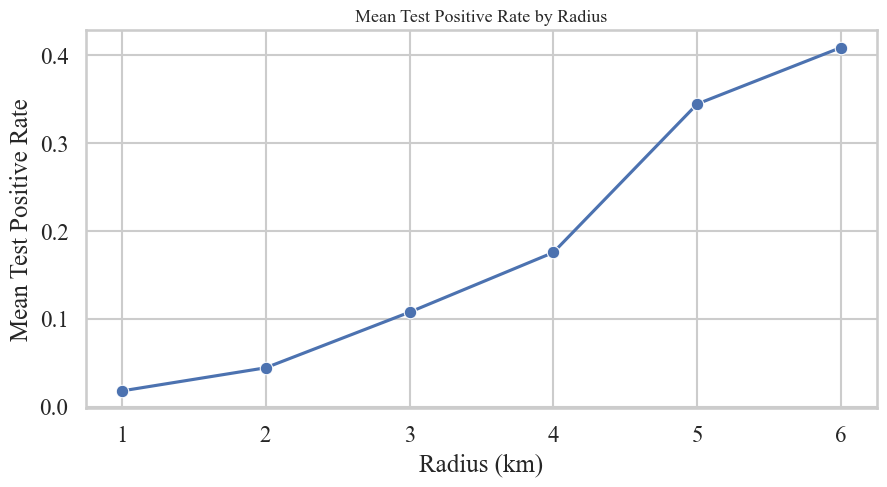

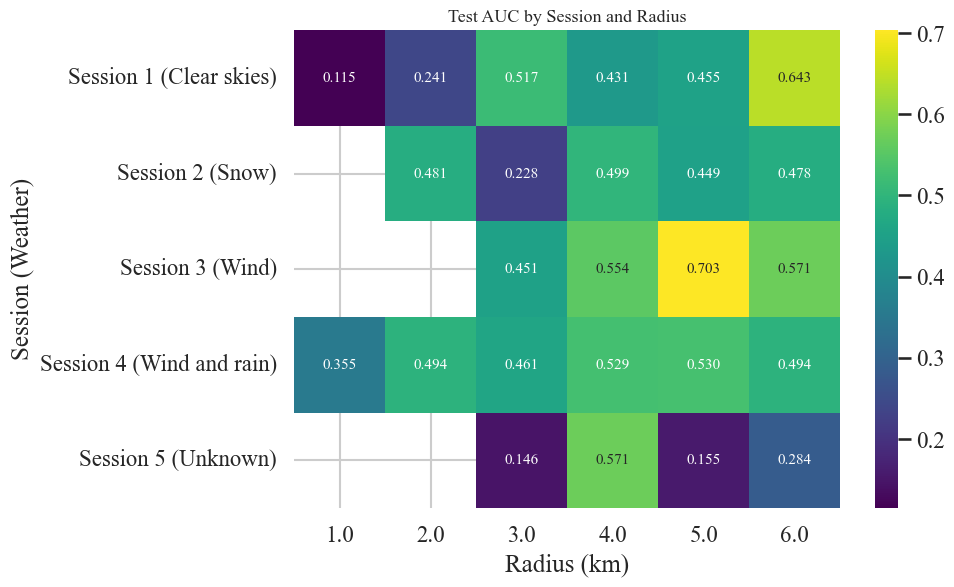

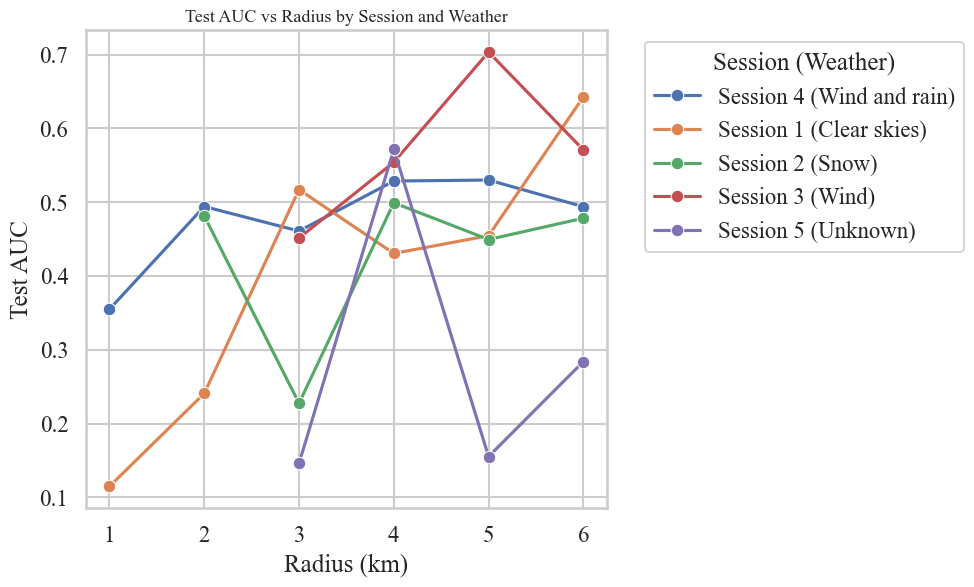

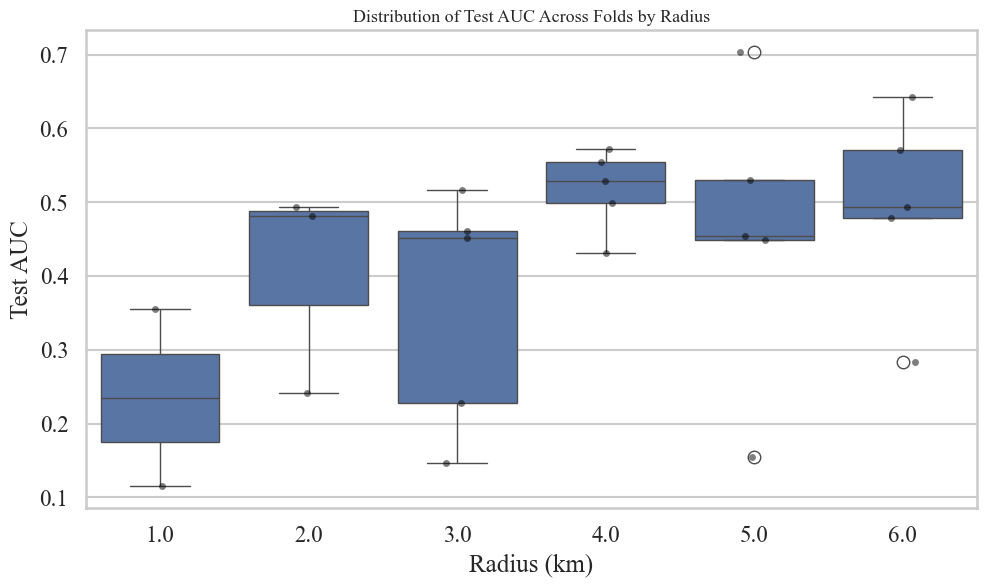

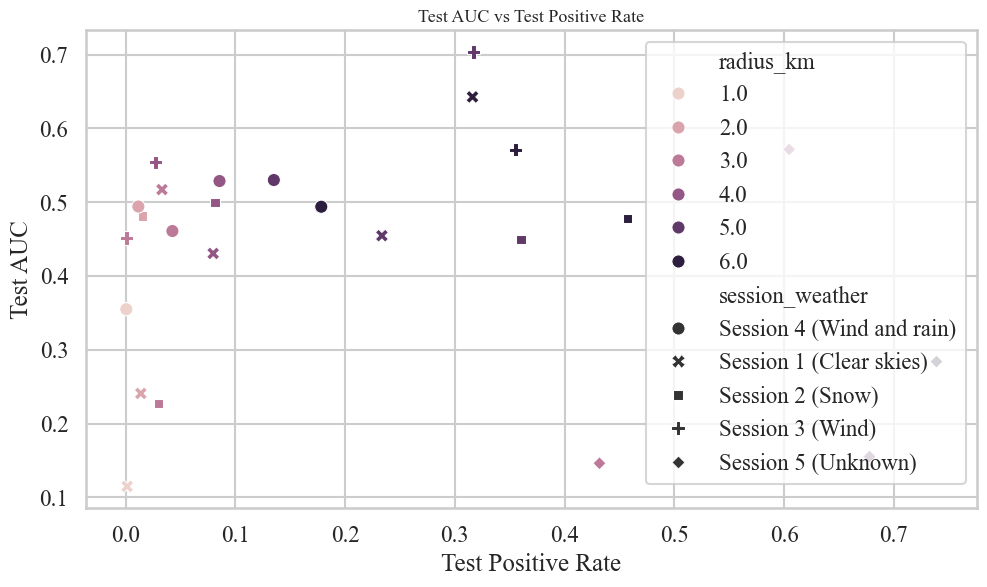

In [26]:
# Generate plots for inline display in notebook
print("Generating figures for display...\n")
make_plots(df=df, radius_summary=radius_summary, out_dir=None, show_inline=True)

## Section 6: Save Figures to Existing Output Locations

Save all figures and summary tables to disk in the outputs directory.

Saving figures...

  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\01_trained_folds_by_radius.pdf
  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\01_trained_folds_by_radius.png


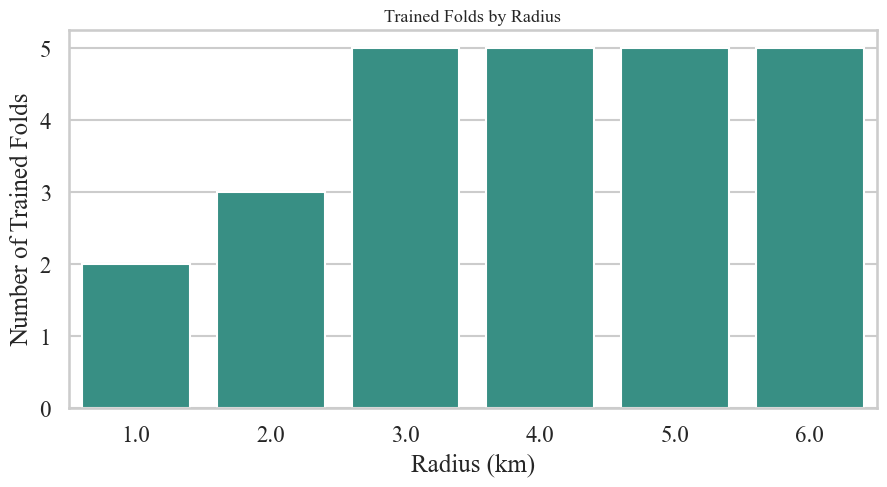

  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\02_skip_rate_by_radius.pdf
  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\02_skip_rate_by_radius.png


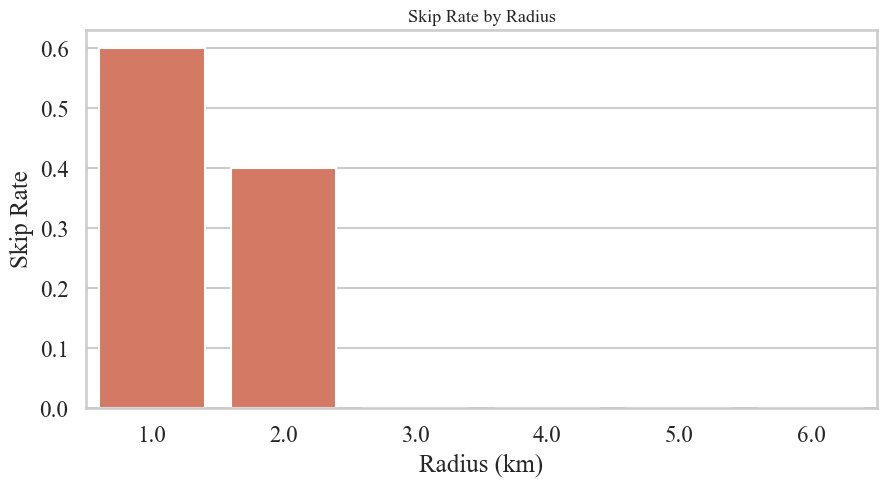

  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\03_test_pos_rate_by_radius.pdf
  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\03_test_pos_rate_by_radius.png


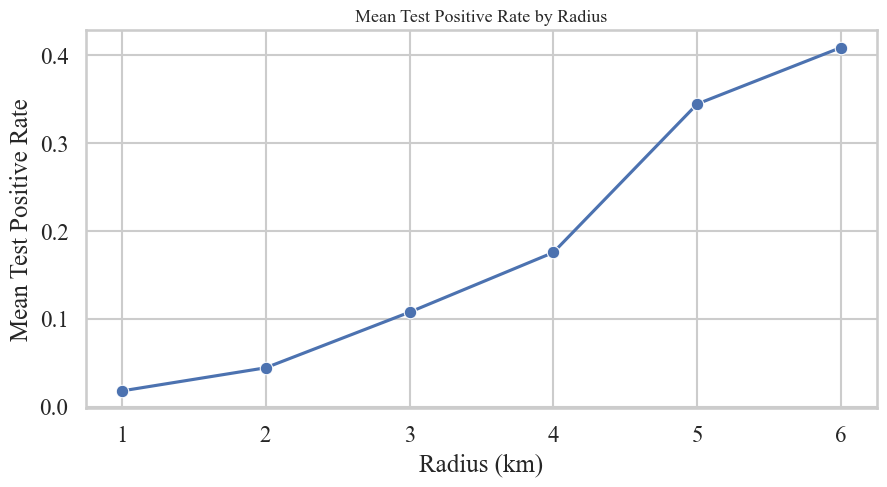

  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\04_heatmap_auc_weather_radius.pdf
  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\04_heatmap_auc_weather_radius.png


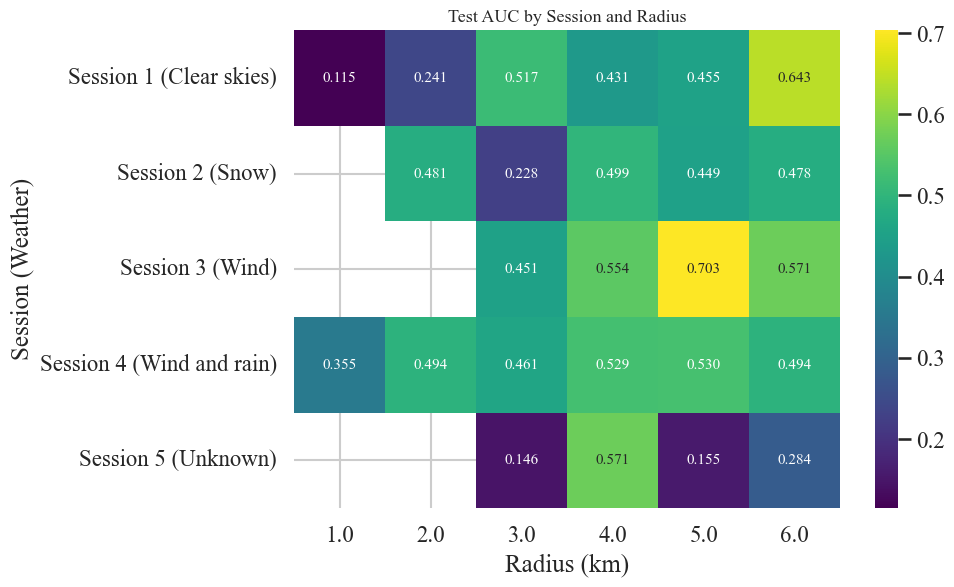

  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\05_lines_auc_by_weather.pdf
  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\05_lines_auc_by_weather.png


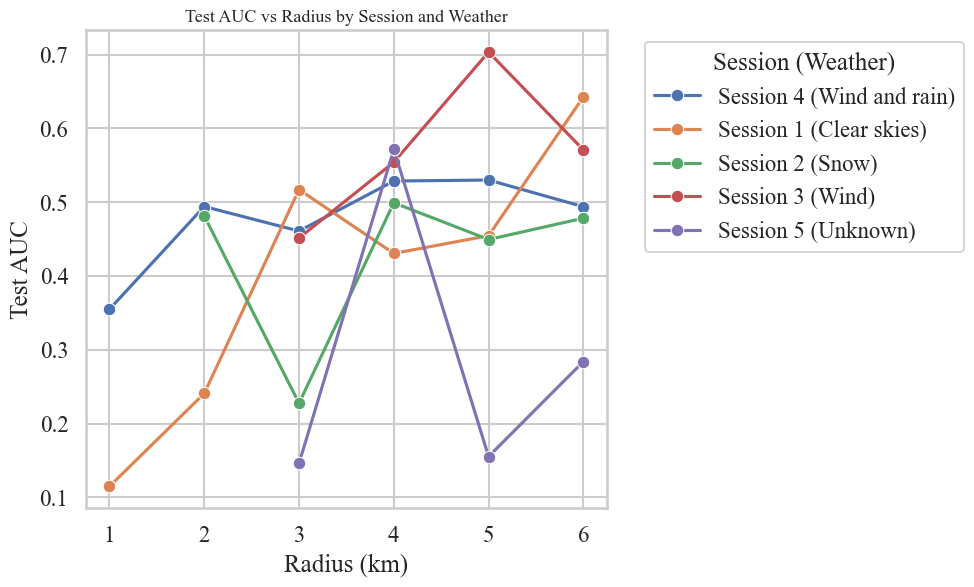

  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\06_box_auc_by_radius.pdf
  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\06_box_auc_by_radius.png


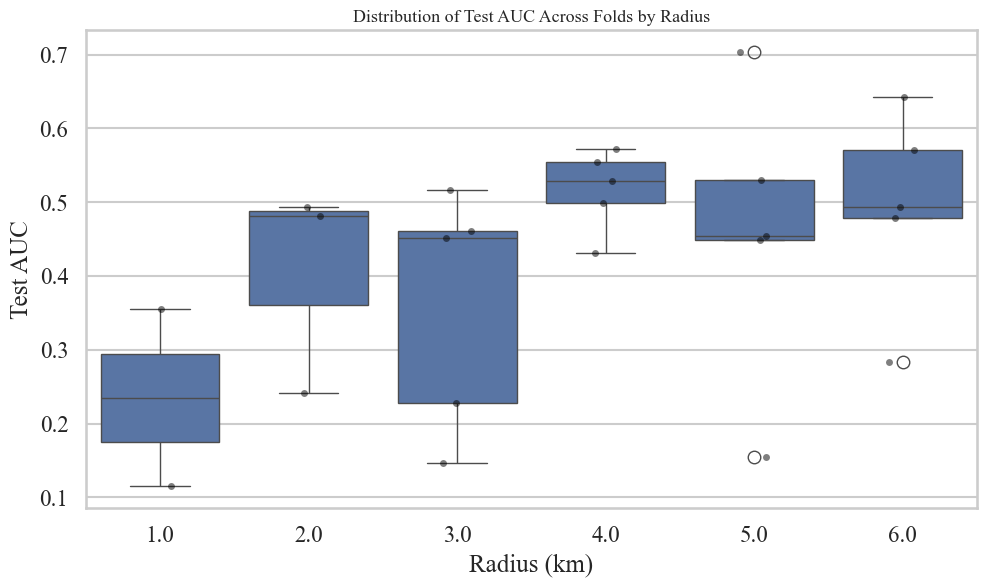

  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\07_scatter_auc_vs_test_pos_rate.pdf
  ✓ Saved: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\07_scatter_auc_vs_test_pos_rate.png


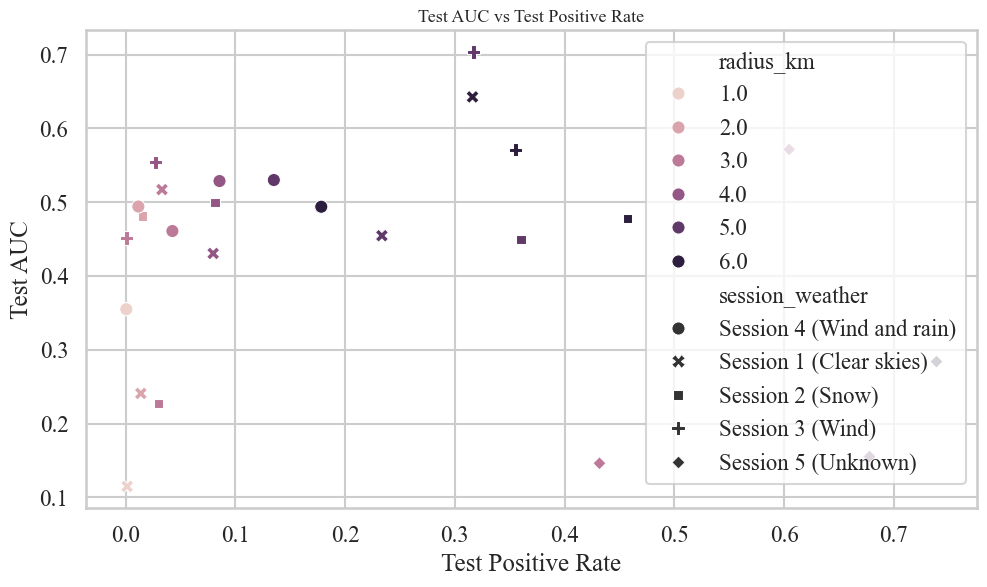


✅ All figures saved to: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis

✓ Saved tidy data: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\radius_fold_tidy.csv
✓ Saved radius summary: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\radius_summary_aggregated.csv
✓ Saved weather-radius summary: C:\Users\imborhau\Documents\sound-event-detection-aircrafts\outputs\radius_weather_analysis\weather_radius_summary.csv


In [27]:
# Save all figures and CSVs to disk
print("Saving figures...\n")
make_plots(df=df, radius_summary=radius_summary, out_dir=OUTPUT_DIR, show_inline=True)

# Save tidy table (all fold-level records)
tidy_path = OUTPUT_DIR / "radius_fold_tidy.csv"
df_tidy = df.sort_values(["radius_km", "fold_id", "trained"], ascending=[True, True, False])
df_tidy.to_csv(tidy_path, index=False)
print(f"\n✓ Saved tidy data: {tidy_path}")

# Save radius summary (aggregated by radius with utility score)
radius_summary_path = OUTPUT_DIR / "radius_summary_aggregated.csv"
radius_summary.to_csv(radius_summary_path, index=False)
print(f"✓ Saved radius summary: {radius_summary_path}")

# Save weather-radius summary
weather_radius_path = OUTPUT_DIR / "weather_radius_summary.csv"
weather_radius_summary.to_csv(weather_radius_path, index=False)
print(f"✓ Saved weather-radius summary: {weather_radius_path}")

## Section 7: Verify Saved Files and Figure Outputs

Check that all output files were created successfully.

In [28]:
# Verify all files exist
print("Verifying saved files...\n")

expected_files = [
    "radius_fold_tidy.csv",
    "radius_summary_aggregated.csv",
    "weather_radius_summary.csv",
    "01_trained_folds_by_radius.pdf", "01_trained_folds_by_radius.png",
    "02_skip_rate_by_radius.pdf", "02_skip_rate_by_radius.png",
    "03_test_pos_rate_by_radius.pdf", "03_test_pos_rate_by_radius.png",
    "04_heatmap_auc_weather_radius.pdf", "04_heatmap_auc_weather_radius.png",
    "05_lines_auc_by_weather.pdf", "05_lines_auc_by_weather.png",
    "06_box_auc_by_radius.pdf", "06_box_auc_by_radius.png",
    "07_scatter_auc_vs_test_pos_rate.pdf", "07_scatter_auc_vs_test_pos_rate.png",
]

all_exist = True
for fname in expected_files:
    fpath = OUTPUT_DIR / fname
    exists = fpath.exists()
    size_str = f"({fpath.stat().st_size / 1024:.1f} KB)" if exists else "(not found)"
    symbol = "✓" if exists else "✗"
    print(f"{symbol} {fname:45} {size_str}")
    if not exists:
        all_exist = False

print(f"\nAll files created: {all_exist}")

# Display summary statistics
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)

print(f"\nTotal fold records: {len(df)}")
print(f"Trained folds: {df['trained'].sum()}")
print(f"Skipped folds: {(~df['trained']).sum()}")

print(f"\nRadii analyzed: {sorted(df['radius_km'].unique())}")
print(f"Sessions: {sorted(df['session'].unique())}")

print("\nUtility Score by Radius (lambda={:.1f}):".format(LAMBDA_SKIP_PENALTY))
print(radius_summary[["radius_km", "num_trained", "skip_rate", "mean_test_auc", "utility"]].to_string(index=False))

# Best radius by utility
candidate = radius_summary.dropna(subset=["utility"])
if not candidate.empty:
    best = candidate.sort_values("utility", ascending=False).iloc[0]
    print(f"\n🏆 Best Radius: {best['radius_km']:.1f} km (utility = {best['utility']:.4f})")

print(f"\n📁 Output directory: {OUTPUT_DIR}")

Verifying saved files...

✓ radius_fold_tidy.csv                          (5.9 KB)
✓ radius_summary_aggregated.csv                 (0.9 KB)
✓ weather_radius_summary.csv                    (2.6 KB)
✓ 01_trained_folds_by_radius.pdf                (15.4 KB)
✓ 01_trained_folds_by_radius.png                (54.1 KB)
✓ 02_skip_rate_by_radius.pdf                    (13.7 KB)
✓ 02_skip_rate_by_radius.png                    (53.1 KB)
✓ 03_test_pos_rate_by_radius.pdf                (15.4 KB)
✓ 03_test_pos_rate_by_radius.png                (85.8 KB)
✓ 04_heatmap_auc_weather_radius.pdf             (22.3 KB)
✓ 04_heatmap_auc_weather_radius.png             (164.9 KB)
✓ 05_lines_auc_by_weather.pdf                   (21.4 KB)
✓ 05_lines_auc_by_weather.png                   (224.1 KB)
✓ 06_box_auc_by_radius.pdf                      (20.9 KB)
✓ 06_box_auc_by_radius.png                      (76.5 KB)
✓ 07_scatter_auc_vs_test_pos_rate.pdf           (22.0 KB)
✓ 07_scatter_auc_vs_test_pos_rate.png          

## Summary

This notebook has completed a full analysis of your radius hyperparameter search:

1. **Loaded data** from all 6 radius summary JSON files (~1-6 km)
2. **Extracted metrics** for all trained and skipped folds
3. **Aggregated results** by radius and by session/weather combination
4. **Generated 7 visualizations**:
   - Feasibility metrics (trained folds, skip rate, positive rate)
   - Performance heatmap and line plots showing AUC across radii and weather conditions
   - Distribution analysis and scatter plots
5. **Saved all outputs** to `outputs/radius_weather_analysis/`:
   - 3 CSV files with fold-level and aggregated data
   - 7 PNG figures at 220 DPI

**To modify mappings:** Edit the `FOLD_TO_SESSION` and `SESSION_TO_WEATHER` dictionaries in Section 3, then re-run Sections 5-7.

**To use a different results directory:** Change `RESULTS_ROOT` in Section 3 and re-run all analysis sections.